<a href="https://colab.research.google.com/github/RazyAnas/MachineLearning/blob/main/space_titanic_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1349]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [1350]:
# http://kaggle.com/competitions/spaceship-titanic

# df1 = pd.read_csv('test-1.csv')
df = pd.read_csv('train-1.csv')

# df = pd.concat([df1, df2], axis=0)

In [1351]:
# df.to_csv('space-titanic.csv')

In [1352]:
df.sample(5)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
656,0686_01,Mars,True,F/146/P,TRAPPIST-1e,18.0,False,0.0,0.0,0.0,0.0,0.0,Permit Bert,True
5094,5441_01,Europa,True,B/207/S,55 Cancri e,24.0,False,0.0,0.0,0.0,0.0,0.0,Raston Spoilling,True
6937,7359_01,Earth,False,E/492/S,PSO J318.5-22,21.0,False,0.0,434.0,0.0,75.0,135.0,Ellana Jenson,True
5414,5780_03,Europa,True,B/195/P,55 Cancri e,21.0,False,0.0,0.0,0.0,0.0,0.0,Betenar Ousious,True
5684,6030_05,Earth,True,G/981/S,TRAPPIST-1e,15.0,False,0.0,0.0,NaN,0.0,0.0,Mollen Ellson,True


In [1353]:
df.size

121702

In [1354]:
df.isnull().mean()*100 # missing in percentage

,0
PassengerId,0.000000
HomePlanet,2.312205
CryoSleep,2.496261
Cabin,2.289198
Destination,2.093639
Age,2.059128
VIP,2.335212
RoomService,2.082135
FoodCourt,2.105142
ShoppingMall,2.392730


In [1355]:
df.nunique()

,0
PassengerId,8693
HomePlanet,3
CryoSleep,2
Cabin,6560
Destination,3
Age,80
VIP,2
RoomService,1273
FoodCourt,1507
ShoppingMall,1115


In [1356]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [1357]:
df.corr(numeric_only=True)

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
Age,1.000000,0.068723,0.130421,0.033133,0.123970,0.101007,-0.075026
RoomService,0.068723,1.000000,-0.015889,0.054480,0.010080,-0.019581,-0.244611
FoodCourt,0.130421,-0.015889,1.000000,-0.014228,0.221891,0.227995,0.046566
ShoppingMall,0.033133,0.054480,-0.014228,1.000000,0.013879,-0.007322,0.010141
Spa,0.123970,0.010080,0.221891,0.013879,1.000000,0.153821,-0.221131
VRDeck,0.101007,-0.019581,0.227995,-0.007322,0.153821,1.000000,-0.207075
Transported,-0.075026,-0.244611,0.046566,0.010141,-0.221131,-0.207075,1.000000


<Axes: >

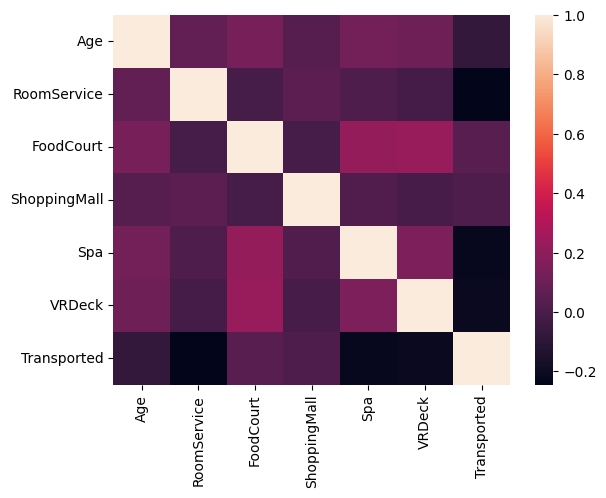

In [1358]:
sns.heatmap(df.corr(numeric_only=True))

<Axes: ylabel='Density'>

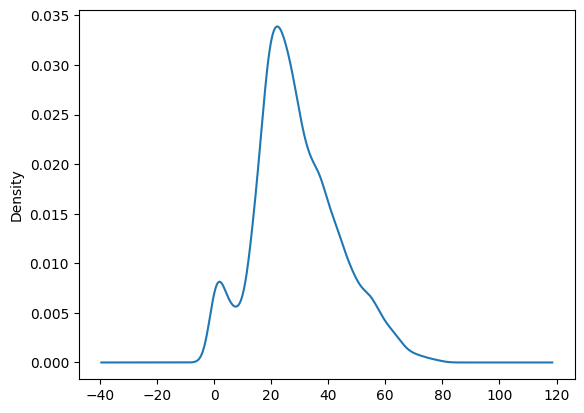

In [1359]:
df['Age'].plot(kind='kde')

In [1360]:
df.isnull().mean()*100

,0
PassengerId,0.000000
HomePlanet,2.312205
CryoSleep,2.496261
Cabin,2.289198
Destination,2.093639
Age,2.059128
VIP,2.335212
RoomService,2.082135
FoodCourt,2.105142
ShoppingMall,2.392730


In [1361]:
# Feature Extraction
# RoomService, FoodCourt, ShoppingMall, Spa, VRDeck --> LuxuryBill

df['LuxuryBill'] = df[['RoomService',
                       'FoodCourt',
                       'ShoppingMall',
                       'Spa',
                       'VRDeck']].sum(axis=1)

In [1362]:
df['PassengerId'] = df['PassengerId'].astype(str)

df['Family'] = (
    df['PassengerId']
    .str.split('_')
    .str[1]
    .astype(int) > 1
)

In [1363]:

df.drop(columns=['PassengerId'],
        inplace=True)

In [1364]:
df['LuxuryBill'].nunique()

2336

In [1365]:
# Feature Decomposition / Splitting
df[['Deck', 'CabinNum', 'Side']] = df['Cabin'].str.split('/', expand=True)

In [1366]:
df.drop(['Cabin'], axis=1, inplace=True)

In [1367]:
df.drop(columns=['Name'], inplace=True)

# Handling missing data

In [1368]:
mask = (
    (df['LuxuryBill']== 0)
    &
    (df['CryoSleep'].isna())
)

df.loc[mask, 'CryoSleep'] = True

In [1369]:
df['CryoSleep'].isnull().sum() # deal rest with most frequent

np.int64(119)

In [1370]:
df['VIP'] = df['VIP'].fillna(df['VIP'].mode()[0])

/tmp/ipykernel_3991/782925514.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['VIP'] = df['VIP'].fillna(df['VIP'].mode()[0])


In [1371]:
df['VIP'].isnull().sum()

np.int64(0)

In [1372]:
df['Deck'] = df['Deck'].fillna('unknown')

In [1373]:
df['Side'] = df['Side'].fillna('unknown')

In [1374]:
df['HomePlanet'] = df['HomePlanet'].fillna('unknown')

In [1375]:
df['Destination'] = df['Destination'].fillna('unknown')

In [1376]:
df['CabinNum'] =  df['CabinNum'].astype(float)

In [1377]:
df['CabinNum'] = df['CabinNum'].fillna(
    df['CabinNum'].astype(float).median()
)

In [1378]:
df['CryoSleep'] = df['CryoSleep'].fillna(
    df['CryoSleep'].mode()[0]
)

/tmp/ipykernel_3991/2578563249.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['CryoSleep'] = df['CryoSleep'].fillna(


# Train Test Split

In [1379]:
from sklearn.model_selection import train_test_split

In [1380]:
X = df.drop('Transported', axis=1)
y = df['Transported']

In [1381]:
X_train ,X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [1382]:
X_train

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,LuxuryBill,Family,Deck,CabinNum,Side
2333,Earth,False,TRAPPIST-1e,28.0,False,0.0,55.0,0.0,656.0,0.0,711.0,False,unknown,427.0,unknown
2589,Earth,False,TRAPPIST-1e,17.0,False,0.0,1195.0,31.0,0.0,0.0,1226.0,True,F,575.0,P
8302,Europa,True,55 Cancri e,28.0,False,0.0,0.0,0.0,0.0,0.0,0.0,True,C,329.0,S
8177,Mars,False,TRAPPIST-1e,20.0,False,NaN,2.0,289.0,976.0,0.0,1267.0,True,F,1800.0,P
500,Europa,True,55 Cancri e,36.0,False,0.0,0.0,0.0,0.0,0.0,0.0,True,C,18.0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,Earth,False,TRAPPIST-1e,18.0,False,14.0,2.0,144.0,610.0,0.0,770.0,False,G,988.0,S
5191,Mars,False,TRAPPIST-1e,50.0,False,690.0,0.0,30.0,762.0,428.0,1910.0,False,F,1063.0,S
5390,Earth,False,PSO J318.5-22,22.0,False,158.0,0.0,476.0,0.0,26.0,660.0,True,F,1194.0,P
860,Mars,False,TRAPPIST-1e,34.0,False,379.0,0.0,1626.0,0.0,0.0,2005.0,False,F,191.0,P


In [1383]:
y_train

,Transported
2333,False
2589,False
8302,True
8177,True
500,True
...,...
5734,True
5191,False
5390,False
860,False


In [1384]:
cat_col = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side', 'Family'] # OneHotEncoding
num_col =['CabinNum'] # standard Scaler
age = ['Age'] # try knn and mean
luxury = ['LuxuryBill'] # log transform and then minmaxscaling

In [1385]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer, KNNImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    FunctionTransformer
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score


# =========================
# COLUMN GROUPS
# =========================

cat_col = [
    'HomePlanet',
    'CryoSleep',
    'Destination',
    'VIP',
    'Deck',
    'Side'
]

num_col = ['CabinNum']

age_col = ['Age']

luxury_col = ['RoomService', 'FoodCourt', 'ShoppingMall']

In [1386]:

# CATEGORICAL PIPELINE


cat_pipeline = Pipeline([
    ('imputer',
     SimpleImputer(strategy='most_frequent')),

    ('ohe',
     OneHotEncoder(
         handle_unknown='ignore',
         drop='if_binary'
     ))
])


# CABIN NUMBER PIPELINE


num_pipeline = Pipeline([
    ('imputer',
     SimpleImputer(strategy='median')),

    ('scaler',
     StandardScaler())
])



# AGE PIPELINE


age_pipeline = Pipeline([
    ('imputer',
     SimpleImputer()),

    ('scaler',
     StandardScaler())
])



# LUXURY BILL PIPELINE


luxury_pipeline = Pipeline([
    ('log',
     FunctionTransformer(np.log1p)),

    ('scaler',
     MinMaxScaler())
])


In [1387]:



# COLUMN TRANSFORMER


preprocessor = ColumnTransformer([

    ('cat',
     cat_pipeline,
     cat_col),

    ('num',
     num_pipeline,
     num_col),

    ('age',
     age_pipeline,
     age_col),

    ('luxury',
     luxury_pipeline,
     luxury_col)
])



In [1388]:
!pip install catboost

In [1389]:
# FINAL PIPELINE
from catboost import CatBoostClassifier


pipe = Pipeline([
    ('preprocessor', preprocessor),

    ('model',
     CatBoostClassifier(
         verbose=0,
         random_state=42
     ))
])

In [1390]:
pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore'))]),
                                                  ['HomePlanet', 'CryoSleep',
                                                   'Destination', 'VIP', 'Deck',
                                                   'Side']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['CabinNum']),
                                                 ('age',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age']),
                                                 ('luxury',
                                                  Pipeline(steps=[('log',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['RoomService', 'FoodCourt',
                                                   'ShoppingMall'])])),
                ('model', CatBoostClassifier(random_state=42, verbose=0))])

In [1391]:

# GRID SEARCH PARAMETERS

param_grid = [

    {
        'preprocessor__age__imputer': [
            SimpleImputer(strategy='mean'),
            SimpleImputer(strategy='median')
        ],

        'model': [
            CatBoostClassifier(
                verbose=0,
                random_state=42
            )
        ],

        'model__depth': [
            4,
            6,
            8
        ],

        'model__learning_rate': [
            0.01,
            0.05,
            0.1
        ],

        'model__iterations': [
            100,
            200
        ]
    }
]


# GRID SEARCH


grid = GridSearchCV(
    estimator=pipe,

    param_grid=param_grid,

    cv=5,

    scoring='accuracy',

    n_jobs=-1,

    verbose=2
)



# TRAIN


grid.fit(X_train, y_train)



# BEST RESULTS


print("Best Score:")
print(grid.best_score_)

print("\nBest Params:")
print(grid.best_params_)



# VALIDATION PREDICTIONS


y_pred = grid.predict(X_test)

print("\nValidation Accuracy:")
print(accuracy_score(y_test, y_pred))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Score:
0.7883257736011047

Best Params:
{'model': CatBoostClassifier(random_state=42, verbose=0), 'model__depth': 6, 'model__iterations': 100, 'model__learning_rate': 0.1, 'preprocessor__age__imputer': SimpleImputer(strategy='median')}

Validation Accuracy:
0.7642323174238068


In [1393]:
# =========================
# LOAD TEST DATA
# =========================

test_df = pd.read_csv('test-1.csv')


# =========================
# FEATURE EXTRACTION
# =========================

# LuxuryBill

test_df['LuxuryBill'] = test_df[[
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck'
]].sum(axis=1)


# =========================
# FAMILY FEATURE
# =========================

test_df['PassengerId'] = test_df['PassengerId'].astype(str)

test_df['Family'] = (
    test_df['PassengerId']
    .str.split('_')
    .str[1]
    .astype(int) > 1
)


# =========================
# CABIN SPLIT
# =========================

test_df[['Deck', 'CabinNum', 'Side']] = (
    test_df['Cabin']
    .str.split('/', expand=True)
)


# =========================
# DROP UNUSED COLUMNS
# =========================

test_df.drop(
    columns=['PassengerId', 'Cabin', 'Name'],
    inplace=True
)


# =========================
# HANDLE MISSING VALUES
# =========================

# CryoSleep logic

mask = (
    (test_df['LuxuryBill'] == 0)
    &
    (test_df['CryoSleep'].isna())
)

test_df.loc[mask, 'CryoSleep'] = True


# VIP

test_df['VIP'] = test_df['VIP'].fillna(
    test_df['VIP'].mode()[0]
)


# Deck

test_df['Deck'] = test_df['Deck'].fillna(
    'unknown'
)


# Side

test_df['Side'] = test_df['Side'].fillna(
    'unknown'
)


# HomePlanet

test_df['HomePlanet'] = test_df['HomePlanet'].fillna(
    'unknown'
)


# Destination

test_df['Destination'] = test_df['Destination'].fillna(
    'unknown'
)


# CabinNum

test_df['CabinNum'] = pd.to_numeric(
    test_df['CabinNum'],
    errors='coerce'
)

test_df['CabinNum'] = test_df['CabinNum'].fillna(
    test_df['CabinNum'].median()
)


# CryoSleep remaining

test_df['CryoSleep'] = test_df['CryoSleep'].fillna(
    test_df['CryoSleep'].mode()[0]
)


# =========================
# PREDICT
# =========================

predictions = grid.predict(test_df)


# =========================
# SUBMISSION FILE
# =========================

submission = pd.DataFrame({
    'PassengerId': pd.read_csv('test-1.csv')['PassengerId'],
    'Transported': predictions
})


# =========================
# SAVE CSV
# =========================

submission.to_csv(
    'submission.csv',
    index=False
)


print("submission.csv created successfully")

submission.csv created successfully


/tmp/ipykernel_3991/916341407.py:74: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['VIP'] = test_df['VIP'].fillna(
/tmp/ipykernel_3991/916341407.py:121: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['CryoSleep'] = test_df['CryoSleep'].fillna(
